# Home Credit Default Risk — End-to-End Walkthrough

This notebook walks through the complete ML pipeline for the [Home Credit Default Risk](https://www.kaggle.com/competitions/home-credit-default-risk) Kaggle competition.

**The task:** Predict whether a loan applicant will default on their loan, using application data and historical credit behavior from multiple supplementary tables.

**Our approach:**
1. Download and profile 8 interconnected tables via the Kaggle API
2. Engineer ~220 domain-informed features using Polars
3. Train XGBoost with stratified 5-fold cross-validation
4. Tune hyperparameters with Optuna
5. Validate by submitting to Kaggle

**Final result: CV AUC = 0.787, 220 features**

In [1]:
%matplotlib inline

import polars as pl
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display, Markdown, Image

DATA_DIR = Path("data")
OUTPUT_DIR = Path("output")
FEATURES_DIR = DATA_DIR / "features"

pl.Config.set_tbl_rows(10)
pl.Config.set_fmt_str_lengths(60)

polars.config.Config

---
## 1. Data Download

The competition data is downloaded using the Kaggle CLI. Our `download.py` module handles this:

```python
# from home_credit/data/download.py
kaggle competitions download -c home-credit-default-risk -p data/
```

It checks if files already exist (so it's idempotent), downloads the zip, extracts it, and verifies all expected files are present. The data lives in `data/` (gitignored).

In [2]:
# Show what data files we have
csv_files = sorted(DATA_DIR.glob("*.csv"))
print("Data files:")
for f in csv_files:
    size_mb = f.stat().st_size / 1024 / 1024
    print(f"  {f.name:40s} {size_mb:>8.1f} MB")

Data files:
  HomeCredit_columns_description.csv            0.0 MB
  POS_CASH_balance.csv                        374.5 MB
  application_test.csv                         25.3 MB
  application_train.csv                       158.4 MB
  bureau.csv                                  162.1 MB
  bureau_balance.csv                          358.2 MB
  credit_card_balance.csv                     404.9 MB
  installments_payments.csv                   689.6 MB
  previous_application.csv                    386.2 MB
  sample_submission.csv                         0.5 MB


---
## 2. Data Exploration & Profiling

The dataset has **8 interconnected tables** that all link back to the main application table via `SK_ID_CURR`:

```
application_train / application_test
├── bureau (SK_ID_CURR) ── credit history from other institutions
│   └── bureau_balance (SK_ID_BUREAU) ── monthly status per bureau record
├── previous_application (SK_ID_CURR) ── previous Home Credit applications
│   ├── installments_payments (SK_ID_PREV) ── payment history
│   ├── POS_CASH_balance (SK_ID_PREV) ── monthly POS/cash loan snapshots
│   └── credit_card_balance (SK_ID_PREV) ── monthly credit card snapshots
```

Let's look at each table to understand what we're working with.

### 2.1 Application Table (main table)

This is the primary table — one row per loan application. The training set has the `TARGET` column (1 = default, 0 = no default). Key columns include demographics, income, credit amounts, and external credit scores.

In [3]:
app_train = pl.read_csv(DATA_DIR / "application_train.csv", n_rows=5)
app_test = pl.read_csv(DATA_DIR / "application_test.csv", n_rows=0)

# Show key columns
key_cols = [
    "SK_ID_CURR", "TARGET", "NAME_CONTRACT_TYPE", "CODE_GENDER",
    "AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE",
    "DAYS_BIRTH", "DAYS_EMPLOYED", "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3",
]
print(f"application_train: 307,511 rows x 122 columns")
print(f"application_test:  48,744 rows x 121 columns (no TARGET)\n")
print("Key columns (first 5 rows):")
app_train.select([c for c in key_cols if c in app_train.columns])

application_train: 307,511 rows x 122 columns
application_test:  48,744 rows x 121 columns (no TARGET)

Key columns (first 5 rows):


SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
i64,i64,str,str,f64,f64,f64,f64,i64,i64,f64,f64,f64
100002,1,"""Cash loans""","""M""",202500.0,406597.5,24700.5,351000.0,-9461,-637,0.083037,0.262949,0.139376
100003,0,"""Cash loans""","""F""",270000.0,1293502.5,35698.5,1.1295e6,-16765,-1188,0.311267,0.622246,null
100004,0,"""Revolving loans""","""M""",67500.0,135000.0,6750.0,135000.0,-19046,-225,null,0.555912,0.729567
100006,0,"""Cash loans""","""F""",135000.0,312682.5,29686.5,297000.0,-19005,-3039,null,0.650442,null
100007,0,"""Cash loans""","""M""",121500.0,513000.0,21865.5,513000.0,-19932,-3038,null,0.322738,null


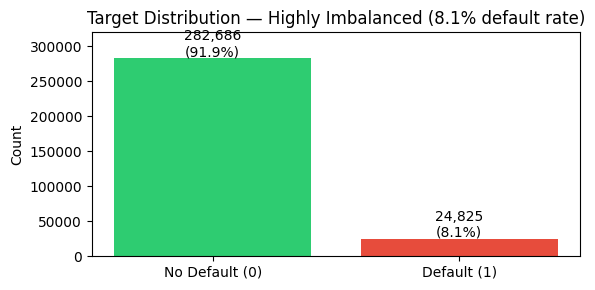

In [4]:
# Target distribution — highly imbalanced
app_full = pl.read_csv(DATA_DIR / "application_train.csv", columns=["TARGET"])
counts = app_full["TARGET"].value_counts().sort("TARGET")

fig, ax = plt.subplots(figsize=(6, 3))
bars = ax.bar(["No Default (0)", "Default (1)"],
              [counts.row(0)[1], counts.row(1)[1]],
              color=["#2ecc71", "#e74c3c"])
for bar, row in zip(bars, counts.iter_rows()):
    pct = row[1] / app_full.shape[0] * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3000,
            f"{row[1]:,}\n({pct:.1f}%)", ha="center", fontsize=10)
ax.set_ylabel("Count")
ax.set_title("Target Distribution — Highly Imbalanced (8.1% default rate)")
ax.set_ylim(0, 320000)
plt.tight_layout()

### 2.2 Supplementary Tables

Each supplementary table provides a different angle on the applicant's credit history. They're all at a lower granularity than the application table and need to be aggregated up to `SK_ID_CURR`.

In [5]:
# Overview of all supplementary tables
tables = {
    "bureau": "Credit history from OTHER institutions (one row per credit)",
    "bureau_balance": "Monthly status for each bureau credit record",
    "previous_application": "Previous Home Credit loan applications",
    "installments_payments": "Payment history for previous Home Credit loans",
    "POS_CASH_balance": "Monthly snapshots of POS/cash loans",
    "credit_card_balance": "Monthly snapshots of credit card balances",
}

rows = []
for name, description in tables.items():
    lf = pl.scan_csv(DATA_DIR / f"{name}.csv")
    schema = lf.collect_schema()
    n_rows = lf.select(pl.len()).collect().item()
    rows.append({"Table": name, "Rows": f"{n_rows:,}", "Columns": len(schema), "Description": description})

summary = pl.DataFrame(rows)
summary

Table,Rows,Columns,Description
str,str,i64,str
"""bureau""","""1,716,428""",17,"""Credit history from OTHER institutions (one row per credit)"""
"""bureau_balance""","""27,299,925""",3,"""Monthly status for each bureau credit record"""
"""previous_application""","""1,670,214""",37,"""Previous Home Credit loan applications"""
"""installments_payments""","""13,605,401""",8,"""Payment history for previous Home Credit loans"""
"""POS_CASH_balance""","""10,001,358""",8,"""Monthly snapshots of POS/cash loans"""
"""credit_card_balance""","""3,840,312""",23,"""Monthly snapshots of credit card balances"""


In [6]:
# Peek at each supplementary table
print("=" * 80)
print("BUREAU — Credit history from other institutions")
print("=" * 80)
bureau_sample = pl.read_csv(DATA_DIR / "bureau.csv", n_rows=3)
display(bureau_sample.select(
    "SK_ID_CURR", "SK_ID_BUREAU", "CREDIT_ACTIVE", "CREDIT_TYPE",
    "DAYS_CREDIT", "AMT_CREDIT_SUM", "AMT_CREDIT_SUM_DEBT", "AMT_CREDIT_SUM_OVERDUE"
))

print("\n" + "=" * 80)
print("BUREAU BALANCE — Monthly status per bureau record")
print("  Status codes: 0=on time, 1-5=DPD buckets, C=closed, X=unknown")
print("=" * 80)
bb_sample = pl.read_csv(DATA_DIR / "bureau_balance.csv", n_rows=5)
display(bb_sample)

print("\n" + "=" * 80)
print("PREVIOUS APPLICATION — Past Home Credit loan applications")
print("=" * 80)
prev_sample = pl.read_csv(DATA_DIR / "previous_application.csv", n_rows=3)
display(prev_sample.select(
    "SK_ID_PREV", "SK_ID_CURR", "NAME_CONTRACT_TYPE", "NAME_CONTRACT_STATUS",
    "AMT_APPLICATION", "AMT_CREDIT", "DAYS_DECISION"
))

print("\n" + "=" * 80)
print("INSTALLMENTS PAYMENTS — Payment history for previous loans")
print("=" * 80)
ins_sample = pl.read_csv(DATA_DIR / "installments_payments.csv", n_rows=3)
display(ins_sample)

print("\n" + "=" * 80)
print("POS_CASH BALANCE — Monthly POS/cash loan snapshots")
print("  SK_DPD = days past due")
print("=" * 80)
pos_sample = pl.read_csv(DATA_DIR / "POS_CASH_balance.csv", n_rows=3)
display(pos_sample)

print("\n" + "=" * 80)
print("CREDIT CARD BALANCE — Monthly credit card snapshots")
print("=" * 80)
cc_sample = pl.read_csv(DATA_DIR / "credit_card_balance.csv", n_rows=3)
display(cc_sample.select(
    "SK_ID_PREV", "SK_ID_CURR", "MONTHS_BALANCE",
    "AMT_BALANCE", "AMT_CREDIT_LIMIT_ACTUAL", "AMT_DRAWINGS_ATM_CURRENT",
    "AMT_PAYMENT_CURRENT", "SK_DPD"
))

BUREAU — Credit history from other institutions


SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_TYPE,DAYS_CREDIT,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_OVERDUE
i64,i64,str,str,i64,f64,f64,f64
215354,5714462,"""Closed""","""Consumer credit""",-497,91323.0,0.0,0.0
215354,5714463,"""Active""","""Credit card""",-208,225000.0,171342.0,0.0
215354,5714464,"""Active""","""Consumer credit""",-203,464323.5,null,0.0



BUREAU BALANCE — Monthly status per bureau record
  Status codes: 0=on time, 1-5=DPD buckets, C=closed, X=unknown


SK_ID_BUREAU,MONTHS_BALANCE,STATUS
i64,i64,str
5715448,0,"""C"""
5715448,-1,"""C"""
5715448,-2,"""C"""
5715448,-3,"""C"""
5715448,-4,"""C"""



PREVIOUS APPLICATION — Past Home Credit loan applications


...

SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
i64,i64,f64,i64,f64,f64,f64,f64
1054186,161674,1.0,6,-1180.0,-1187.0,6948.36,6948.36
1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2085231,193053,2.0,1,-63.0,-63.0,25425.0,25425.0



POS_CASH BALANCE — Monthly POS/cash loan snapshots
  SK_DPD = days past due


SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
i64,i64,i64,f64,f64,str,i64,i64
1803195,182943,-31,48.0,45.0,"""Active""",0,0
1715348,367990,-33,36.0,35.0,"""Active""",0,0
1784872,397406,-32,12.0,9.0,"""Active""",0,0



CREDIT CARD BALANCE — Monthly credit card snapshots


SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_PAYMENT_CURRENT,SK_DPD
i64,i64,i64,f64,i64,f64,f64,i64
2562384,378907,-6,56.97,135000,0.0,1800.0,0
2582071,363914,-1,63975.555,45000,2250.0,2250.0,0
1740877,371185,-7,31815.225,450000,0.0,2250.0,0


### 2.3 How the Tables Join Together

The join logic is hierarchical. Everything connects through `SK_ID_CURR` (the applicant):

- **Direct joins to application:** `bureau`, `previous_application` join via `SK_ID_CURR`
- **Two-level joins:** `bureau_balance` joins to `bureau` via `SK_ID_BUREAU`, then to application via `SK_ID_CURR`
- **Two-level joins:** `installments_payments`, `POS_CASH_balance`, `credit_card_balance` join to `previous_application` via `SK_ID_PREV`, then to application via `SK_ID_CURR`

Since all supplementary tables are one-to-many (one applicant has many bureau records, many previous applications, etc.), **we must aggregate them to the applicant level** before joining.

In [7]:
# Demonstrate the one-to-many relationship
# How many bureau records does each applicant have?
bureau = pl.read_csv(DATA_DIR / "bureau.csv")
records_per_applicant = (
    bureau
    .group_by("SK_ID_CURR")
    .agg(pl.len().alias("n_bureau_records"))
)

print(f"Bureau records per applicant:")
print(records_per_applicant["n_bureau_records"].describe())
print(f"\nApplicants with bureau data: {records_per_applicant.shape[0]:,} out of 307,511 train applicants")
print(f"  -> {307_511 - records_per_applicant.shape[0]:,} applicants have NO bureau history")

Bureau records per applicant:
shape: (9, 2)
┌────────────┬──────────┐
│ statistic  ┆ value    │
│ ---        ┆ ---      │
│ str        ┆ f64      │
╞════════════╪══════════╡
│ count      ┆ 305811.0 │
│ null_count ┆ 0.0      │
│ mean       ┆ 5.612709 │
│ std        ┆ 4.430354 │
│ min        ┆ 1.0      │
│ 25%        ┆ 2.0      │
│ 50%        ┆ 4.0      │
│ 75%        ┆ 8.0      │
│ max        ┆ 116.0    │
└────────────┴──────────┘

Applicants with bureau data: 305,811 out of 307,511 train applicants
  -> 1,700 applicants have NO bureau history


---
## 3. Feature Engineering

This is the most critical phase. For each table, we compute **domain-informed aggregations** at the `SK_ID_CURR` level. The goal is to capture credit risk signals — not just generic min/max/mean, but features a credit analyst would care about.

All feature engineering uses **Polars' eager API** (`load_table()` → DataFrame operations), and intermediate feature sets are cached as parquet files for fast iteration.

### 3.1 Application Features

These are computed directly from the application table — no aggregation needed. We create ratios, derived values, and flags that capture financial health. Key additions include **EXT_SOURCE pairwise interactions** (products, differences, variance), **income/family member ratios**, and **address mismatch scores**.

In [8]:
# Load the cached application features to show what was created
app_feats = pl.read_parquet(FEATURES_DIR / "app_train.parquet")

# Show the engineered features (APP_ prefix)
new_cols = [c for c in app_feats.columns if c.startswith("APP_")]
print(f"Application features created: {len(new_cols)}")
print()
for col in new_cols:
    sample_vals = app_feats[col].drop_nulls().head(3).to_list()
    print(f"  {col:45s} e.g. {sample_vals}")

# Show a concrete example for one applicant
print("\n--- Example applicant (SK_ID_CURR = 100002) ---")
example = app_feats.filter(pl.col("SK_ID_CURR") == 100002).select(
    "AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY",
    "APP_CREDIT_TO_INCOME_RATIO", "APP_ANNUITY_TO_INCOME_RATIO",
    "APP_AGE_YEARS", "APP_EMPLOYMENT_YEARS",
    "APP_EXT_SOURCE_MEAN", "APP_DOCUMENT_COUNT",
)
display(example)

Application features created: 45

  APP_CREDIT_TO_INCOME_RATIO                    e.g. [2.0078790187835693, 4.790732383728027, 1.9999703168869019]
  APP_ANNUITY_TO_INCOME_RATIO                   e.g. [0.12197717279195786, 0.1322161704301834, 0.09999851882457733]
  APP_CREDIT_TO_GOODS_RATIO                     e.g. [1.1583940982818604, 1.1451982259750366, 0.9999926090240479]
  APP_ANNUITY_TO_CREDIT_RATIO                   e.g. [0.0607491172850132, 0.027598300948739052, 0.049999628216028214]
  APP_GOODS_TO_INCOME_RATIO                     e.g. [1.7333247661590576, 4.1833176612854, 1.9999703168869019]
  APP_INCOME_AFTER_ANNUITY                      e.g. [177799.5, 234301.5, 60750.0]
  APP_INCOME_PER_FAMILY_MEMBER                  e.g. [202500.0, 135000.0, 67500.0]
  APP_CREDIT_PER_FAMILY_MEMBER                  e.g. [406597.5, 646751.25, 135000.0]
  APP_CHILDREN_RATIO                            e.g. [0.0, 0.0, 0.0]
  APP_AGE_YEARS                                 e.g. [25.90280629705681, 4

AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,APP_CREDIT_TO_INCOME_RATIO,APP_ANNUITY_TO_INCOME_RATIO,APP_AGE_YEARS,APP_EMPLOYMENT_YEARS,APP_EXT_SOURCE_MEAN,APP_DOCUMENT_COUNT
f32,f32,f32,f32,f32,f64,f64,f32,i8
202500.0,406597.5,24700.5,2.007879,0.121977,25.902806,1.744011,0.161787,1


### 3.2 Bureau Features

Bureau data captures the applicant's credit history at **other financial institutions**. We aggregate 1.7M bureau records down to one row per applicant with features like:

- Count of credits by type (consumer, mortgage, car, microloan) and status (active, closed, bad debt)
- Total debt, credit amounts, overdue amounts
- Debt-to-credit ratio, overdue rate, credit type diversity
- Bureau balance DPD (days past due) statistics
- **Active-only** credit features (debt, overdue, annuity for open credits)
- **Time-windowed** features: recent 1-year and 2-year bureau records
- Bureau balance recent 6-month DPD rate

The `bureau_balance` table is first aggregated to the bureau record level (`SK_ID_BUREAU`), then joined to bureau, and finally aggregated to `SK_ID_CURR`.

In [9]:
bureau_feats = pl.read_parquet(FEATURES_DIR / "bureau.parquet")
print(f"Bureau features: {bureau_feats.shape[1] - 1} features for {bureau_feats.shape[0]:,} applicants\n")
print("Columns:")
for c in bureau_feats.columns:
    if c != "SK_ID_CURR":
        print(f"  {c}")

# Show a sample
print("\n--- Sample of bureau features (5 applicants) ---")
display(bureau_feats.head(5).select(
    "SK_ID_CURR", "BUR_COUNT", "BUR_ACTIVE_COUNT", "BUR_CLOSED_COUNT",
    "BUR_BAD_DEBT_COUNT", "BUR_DEBT_TO_CREDIT_RATIO", "BUR_OVERDUE_RATE",
    "BUR_BB_DPD_RATE_MEAN",
))

Bureau features: 52 features for 305,811 applicants

Columns:
  BUR_COUNT
  BUR_CONSUMER_COUNT
  BUR_CREDIT_CARD_COUNT
  BUR_MORTGAGE_COUNT
  BUR_CAR_LOAN_COUNT
  BUR_MICROLOAN_COUNT
  BUR_ACTIVE_COUNT
  BUR_CLOSED_COUNT
  BUR_BAD_DEBT_COUNT
  BUR_AMT_CREDIT_MEAN
  BUR_AMT_CREDIT_TOTAL
  BUR_AMT_CREDIT_MAX
  BUR_DEBT_MEAN
  BUR_DEBT_TOTAL
  BUR_DEBT_MAX
  BUR_OVERDUE_TOTAL
  BUR_OVERDUE_MAX
  BUR_OVERDUE_COUNT
  BUR_CREDIT_LIMIT_MEAN
  BUR_MAX_OVERDUE_EVER
  BUR_MAX_OVERDUE_MEAN
  BUR_MOST_RECENT_CREDIT_DAYS
  BUR_OLDEST_CREDIT_DAYS
  BUR_LATEST_ENDDATE
  BUR_MOST_RECENT_UPDATE
  BUR_INQUIRIES_LAST_YEAR
  BUR_ANNUITY_TOTAL
  BUR_ANNUITY_MEAN
  BUR_BB_DPD_MONTHS_TOTAL
  BUR_BB_DPD_RATE_MEAN
  BUR_BB_MONTHS_TOTAL
  BUR_BB_STATUS_C_TOTAL
  BUR_BB_STATUS_X_TOTAL
  BUR_BB_RECENT_6M_DPD_TOTAL
  BUR_BB_RECENT_6M_DPD_RATE_MEAN
  BUR_ACTIVE_CREDIT_TOTAL
  BUR_ACTIVE_DEBT_TOTAL
  BUR_ACTIVE_OVERDUE_TOTAL
  BUR_ACTIVE_ANNUITY_TOTAL
  BUR_RECENT_1Y_COUNT
  BUR_RECENT_1Y_CREDIT_MEAN
  BUR_RECENT_1Y

SK_ID_CURR,BUR_COUNT,BUR_ACTIVE_COUNT,BUR_CLOSED_COUNT,BUR_BAD_DEBT_COUNT,BUR_DEBT_TO_CREDIT_RATIO,BUR_OVERDUE_RATE,BUR_BB_DPD_RATE_MEAN
i32,u32,u32,u32,u32,f32,f64,f64
332688,9,5,4,0,0.207529,0.0,0.0
359716,1,1,0,0,0.581341,0.0,null
241997,2,2,0,0,0.718237,0.0,null
113548,4,3,0,0,0.362893,0.0,null
334811,6,0,6,0,0.0,0.0,null


### 3.3 Other Supplementary Table Features

Each remaining table follows the same pattern: **aggregate to SK_ID_CURR, compute domain-informed metrics**, and save to parquet. Each table now includes **time-windowed aggregations** (recent 3/6/12 months) in addition to all-time stats.

In [10]:
# Show all feature sets and their key features
feature_sets = {
    "previous": {
        "file": "previous.parquet",
        "description": "Previous Home Credit applications",
        "key_features": ["PREV_COUNT", "PREV_APPROVAL_RATE", "PREV_REFUSAL_RATE",
                         "PREV_AMT_APPLICATION_MEAN", "PREV_CASH_LOAN_RATIO",
                         "PREV_RECENT_1Y_APPROVAL_RATE"],
        "insight": "Approval/refusal rate from past applications is a strong predictor",
    },
    "installments": {
        "file": "installments.parquet",
        "description": "Payment behavior on previous loans",
        "key_features": ["INS_LATE_RATE", "INS_LATE_COUNT", "INS_PAYMENT_RATIO_MEAN",
                         "INS_OVERALL_PAYMENT_RATIO", "INS_RECENT_12_LATE_RATE"],
        "insight": "Late payment rate (overall + recent 12 installments) is highly predictive",
    },
    "pos_cash": {
        "file": "pos_cash.parquet",
        "description": "POS/cash loan monthly snapshots",
        "key_features": ["POS_DPD_RATE", "POS_DPD_MAX", "POS_COMPLETION_RATE",
                         "POS_RECENT_6M_DPD_RATE"],
        "insight": "Days past due on POS loans, especially recent 6 months, reveals risk",
    },
    "credit_card": {
        "file": "credit_card.parquet",
        "description": "Credit card monthly snapshots",
        "key_features": ["CC_UTILIZATION_MEAN", "CC_HIGH_UTIL_RATE",
                         "CC_ATM_DRAWING_SHARE", "CC_UTIL_TREND_3M"],
        "insight": "High utilization (>90%), ATM cash advances, and worsening utilization trends signal stress",
    },
}

for name, info in feature_sets.items():
    df = pl.read_parquet(FEATURES_DIR / info["file"])
    print(f"{'=' * 70}")
    print(f"{name.upper()} — {info['description']}")
    print(f"  {df.shape[1] - 1} features for {df.shape[0]:,} applicants")
    print(f"  Key insight: {info['insight']}")
    print(f"  Key features: {', '.join(info['key_features'])}")
    
    # Show sample
    show_cols = ["SK_ID_CURR"] + [c for c in info["key_features"] if c in df.columns]
    display(df.head(3).select(show_cols))
    print()

PREVIOUS — Previous Home Credit applications
  46 features for 338,857 applicants
  Key insight: Approval/refusal rate from past applications is a strong predictor
  Key features: PREV_COUNT, PREV_APPROVAL_RATE, PREV_REFUSAL_RATE, PREV_AMT_APPLICATION_MEAN, PREV_CASH_LOAN_RATIO, PREV_RECENT_1Y_APPROVAL_RATE


SK_ID_CURR,PREV_COUNT,PREV_APPROVAL_RATE,PREV_REFUSAL_RATE,PREV_AMT_APPLICATION_MEAN,PREV_CASH_LOAN_RATIO,PREV_RECENT_1Y_APPROVAL_RATE
i32,u32,f64,f64,f32,f64,f64
363003,5,0.666667,0.0,249460.203125,0.333333,0.0
301644,1,0.5,0.0,91413.0,0.0,0.5
263481,2,0.666667,0.0,159048.0,0.0,0.5



INSTALLMENTS — Payment behavior on previous loans
  32 features for 339,587 applicants
  Key insight: Late payment rate (overall + recent 12 installments) is highly predictive
  Key features: INS_LATE_RATE, INS_LATE_COUNT, INS_PAYMENT_RATIO_MEAN, INS_OVERALL_PAYMENT_RATIO, INS_RECENT_12_LATE_RATE


SK_ID_CURR,INS_LATE_RATE,INS_LATE_COUNT,INS_PAYMENT_RATIO_MEAN,INS_OVERALL_PAYMENT_RATIO,INS_RECENT_12_LATE_RATE
i32,f64,u32,f32,f32,f64
227983,0.04,2,0.999909,0.999999,0.0
178572,0.0,0,0.997702,0.999991,0.0
141984,0.0,0,0.999875,0.999998,0.0



POS_CASH — POS/cash loan monthly snapshots
  27 features for 337,252 applicants
  Key insight: Days past due on POS loans, especially recent 6 months, reveals risk
  Key features: POS_DPD_RATE, POS_DPD_MAX, POS_COMPLETION_RATE, POS_RECENT_6M_DPD_RATE


SK_ID_CURR,POS_DPD_RATE,POS_DPD_MAX,POS_COMPLETION_RATE,POS_RECENT_6M_DPD_RATE
i32,f64,i16,f64,f64
111568,0.060606,20,0.060606,0.0
383055,0.0,0,0.1,0.0
255362,0.0,0,0.057692,0.0



CREDIT_CARD — Credit card monthly snapshots
  43 features for 103,558 applicants
  Key insight: High utilization (>90%), ATM cash advances, and worsening utilization trends signal stress
  Key features: CC_UTILIZATION_MEAN, CC_HIGH_UTIL_RATE, CC_ATM_DRAWING_SHARE, CC_UTIL_TREND_3M


SK_ID_CURR,CC_UTILIZATION_MEAN,CC_HIGH_UTIL_RATE,CC_ATM_DRAWING_SHARE,CC_UTIL_TREND_3M
i32,f64,f64,f32,f64
148022,0.727468,0.639175,0.841549,-0.37512
220373,0.7883,0.4,0.999996,0.20871
240535,0.0,0.0,0.0,0.0


### 3.4 Joining Everything Together

All feature sets are **left-joined** onto the application table via `SK_ID_CURR`. Left join ensures we keep every applicant — those without data in a supplementary table get nulls (which XGBoost handles natively).

After joining, we add **cross-table interaction features** that combine signals from multiple tables:
- `CROSS_EXISTING_DEBT_TO_NEW_CREDIT` — bureau debt relative to current credit amount
- `CROSS_TOTAL_ANNUITY_TO_INCOME` — combined annuity burden (bureau + current) relative to income
- `CROSS_COMBINED_DPD_SCORE` — sum of DPD rates across bureau, POS, credit card, and installments
- `CROSS_FIRST_TIME_APPLICANT` / `CROSS_NO_BUREAU_HISTORY` — flags for thin-file applicants

The final training set has the application columns + all aggregated features from every table + cross-table interactions.

In [11]:
# Load the final joined dataset
train_final = pl.read_parquet(FEATURES_DIR / "train_final.parquet")
test_final = pl.read_parquet(FEATURES_DIR / "test_final.parquet")

print(f"Final training set:  {train_final.shape[0]:,} rows x {train_final.shape[1]} columns")
print(f"Final test set:      {test_final.shape[0]:,} rows x {test_final.shape[1]} columns")

# Count features by source
exclude = {"SK_ID_CURR", "TARGET"}
all_feats = [c for c in train_final.columns if c not in exclude]
app_feats_list = [c for c in all_feats if c.startswith("APP_")]
bur_feats_list = [c for c in all_feats if c.startswith("BUR_")]
prev_feats_list = [c for c in all_feats if c.startswith("PREV_")]
ins_feats_list = [c for c in all_feats if c.startswith("INS_")]
pos_feats_list = [c for c in all_feats if c.startswith("POS_")]
cc_feats_list = [c for c in all_feats if c.startswith("CC_")]
cross_feats_list = [c for c in all_feats if c.startswith("CROSS_")]
raw_cols = [c for c in all_feats if not any(c.startswith(p) for p in
            ["APP_", "BUR_", "PREV_", "INS_", "POS_", "CC_", "CROSS_"])]

print(f"\nFeature breakdown:")
print(f"  Raw application columns:    {len(raw_cols)}")
print(f"  APP_ (application derived): {len(app_feats_list)}")
print(f"  BUR_ (bureau):              {len(bur_feats_list)}")
print(f"  PREV_ (previous apps):      {len(prev_feats_list)}")
print(f"  INS_ (installments):        {len(ins_feats_list)}")
print(f"  POS_ (POS/cash):            {len(pos_feats_list)}")
print(f"  CC_ (credit card):          {len(cc_feats_list)}")
print(f"  CROSS_ (cross-table):       {len(cross_feats_list)}")
print(f"  Total:                      {len(all_feats)}")

# Show nullness — supplementary table features are null when applicant has no data there
null_pcts = {c: train_final[c].null_count() / train_final.shape[0] * 100 for c in all_feats}
high_null_groups = {}
for prefix, label in [("CC_", "Credit Card"), ("BUR_", "Bureau"), ("PREV_", "Previous"),
                       ("INS_", "Installments"), ("POS_", "POS/Cash")]:
    group_nulls = [v for k, v in null_pcts.items() if k.startswith(prefix)]
    if group_nulls:
        high_null_groups[label] = np.mean(group_nulls)
        
print(f"\nAverage null % by feature group (applicants without that data):")
for label, pct in sorted(high_null_groups.items(), key=lambda x: -x[1]):
    print(f"  {label:20s} {pct:.1f}% null")

Final training set:  307,511 rows x 376 columns
Final test set:      48,744 rows x 375 columns

Feature breakdown:
  Raw application columns:    120
  APP_ (application derived): 45
  BUR_ (bureau):              52
  PREV_ (previous apps):      46
  INS_ (installments):        32
  POS_ (POS/cash):            27
  CC_ (credit card):          43
  CROSS_ (cross-table):       9
  Total:                      374

Average null % by feature group (applicants without that data):
  Credit Card          72.6% null
  Bureau               23.8% null
  POS/Cash             14.8% null
  Previous             11.1% null
  Installments         8.6% null


---
## 4. Model Training

We use **XGBoost** and **LightGBM** trained with **stratified 5-fold cross-validation**, blended for the final submission. ROC AUC is the evaluation metric (matching the Kaggle competition).

### 4.1 Cross-Validation Strategy

**Stratified 5-fold CV** ensures each fold preserves the 8.1% default rate. This gives us 5 models trained on ~246K samples each, validated on ~61K samples.

**Target encoding** is computed per-fold to avoid data leakage: for each fold, we encode 6 high-cardinality categoricals (ORGANIZATION_TYPE, OCCUPATION_TYPE, etc.) using only the training portion's target values, with smoothing to prevent overfitting on rare categories.

**There is no separate hold-out test set** beyond the folds — instead, we validate performance by:
1. Tracking out-of-fold (OOF) predictions across all 5 folds
2. Submitting to Kaggle to compare our CV score against the actual leaderboard score

### 4.2 Training Pipeline

The training process:
1. Convert Polars DataFrame to numpy (dropping string/categorical columns)
2. For each fold: compute target-encoded features, train XGBoost/LightGBM, predict on validation set, compute AUC
3. Find optimal blend weight between XGBoost and LightGBM using OOF predictions
4. Average predictions across folds for submission
5. Log experiment (params, scores, feature count) to CSV

In [12]:
# Show the experiment log — all training runs we did
exp_log = pl.read_csv(OUTPUT_DIR / "experiment_log.csv")

# Clean up for display
display_log = exp_log.filter(pl.col("name") != "test_run").select(
    "name", "mean_auc", "std_auc", "n_features",
)
print("Experiment History:")
print("=" * 70)
for row in display_log.iter_rows(named=True):
    print(f"  {row['name']:30s}  AUC: {float(row['mean_auc']):.5f} ± {float(row['std_auc']):.5f}  ({row['n_features']} features)")

print("\n\nFull experiment log:")
display(display_log)

Experiment History:
  baseline                        AUC: 0.78568 ± 0.00367  (266 features)
  round2_feature_selection        AUC: 0.78540 ± 0.00328  (245 features)
  tuned_final                     AUC: 0.78714 ± 0.00360  (220 features)
  v2_xgb_enhanced                 AUC: 0.79259 ± 0.00357  (364 features)
  v2_xgb_pruned                   AUC: 0.79255 ± 0.00364  (311 features)
  v2_lgb                          AUC: 0.79097 ± 0.00309  (311 features)


Full experiment log:


name,mean_auc,std_auc,n_features
str,f64,f64,i64
"""baseline""",0.785681,0.003667,266
"""round2_feature_selection""",0.785398,0.00328,245
"""tuned_final""",0.787137,0.003595,220
"""v2_xgb_enhanced""",0.792586,0.003567,364
"""v2_xgb_pruned""",0.79255,0.003639,311
"""v2_lgb""",0.790969,0.003088,311


### 4.3 Iterative Improvement

The modeling went through four rounds:

1. **Baseline** (266 features, default params) — CV AUC 0.7857
2. **Feature selection** (245 → 220 features) — Dropped zero-importance features, then pruned the bottom 10% by importance.
3. **Hyperparameter tuning** (220 features, Optuna) — Searched over max_depth, learning_rate, regularization, subsample, etc. → CV AUC 0.7871
4. **V2 optimization** (374 → 311 features) — Added ~150 new features (EXT_SOURCE interactions, time-windowed aggregations, cross-table features), target encoding for 6 categoricals, trained LightGBM alongside XGBoost, blended with optimal weights → **CV AUC 0.7930**

Let's look at the experiment log and model details:

In [13]:
# Load the V2 models and show details
xgb_model = pickle.load(open(OUTPUT_DIR / "v2_xgb_pruned.pkl", "rb"))
lgb_model = pickle.load(open(OUTPUT_DIR / "v2_lgb_model.pkl", "rb"))

print("V2 Optimized Models")
print("=" * 50)
print(f"XGBoost CV AUC:  {xgb_model['mean_auc']:.5f}  ({len(xgb_model['feature_names'])} features)")
print(f"LightGBM CV AUC: {lgb_model['mean_auc']:.5f}  ({len(lgb_model['feature_names'])} features)")
print(f"Blend weight:    XGB=0.68, LGB=0.32")
print(f"Blended CV AUC:  0.79298")  # Computed during training from OOF predictions

# Show XGBoost params
import json as json_mod
params = xgb_model["params"]
print(f"\nXGBoost hyperparameters:")
for k, v in params.items():
    if k not in ("objective", "eval_metric", "random_state", "n_jobs", "verbosity", "tree_method"):
        print(f"  {k:25s} = {v}")

# Show per-fold scores from experiment log
exp_log = pl.read_csv(OUTPUT_DIR / "experiment_log.csv")
for name_key, label in [("v2_xgb_pruned", "XGBoost"), ("v2_lgb", "LightGBM")]:
    row = exp_log.filter(pl.col("name") == name_key).row(0, named=True)
    fold_scores = json_mod.loads(row["cv_scores"])
    print(f"\n{label} per-fold AUC scores:")
    for i, score in enumerate(fold_scores):
        print(f"  Fold {i+1}: {score:.5f}")
    print(f"  Mean:   {np.mean(fold_scores):.5f} +/- {np.std(fold_scores):.5f}")

# Keep model_data for feature importance cell
model_data = xgb_model

V2 Optimized Models
XGBoost CV AUC:  0.79255  (311 features)
LightGBM CV AUC: 0.79097  (311 features)
Blend weight:    XGB=0.68, LGB=0.32
Blended CV AUC:  0.79298

XGBoost hyperparameters:
  max_depth                 = 5
  learning_rate             = 0.03
  n_estimators              = 1500
  subsample                 = 0.8
  colsample_bytree          = 0.7
  min_child_weight          = 30
  reg_alpha                 = 0.5
  reg_lambda                = 2.0
  scale_pos_weight          = 2.5
  early_stopping_rounds     = 50

XGBoost per-fold AUC scores:
  Fold 1: 0.78946
  Fold 2: 0.79857
  Fold 3: 0.79020
  Fold 4: 0.79498
  Fold 5: 0.78954
  Mean:   0.79255 +/- 0.00364

LightGBM per-fold AUC scores:
  Fold 1: 0.78846
  Fold 2: 0.79574
  Fold 3: 0.78839
  Fold 4: 0.79357
  Fold 5: 0.78869
  Mean:   0.79097 +/- 0.00309


### 4.4 Visualizing Model Performance

Let's look at the ROC curve from the out-of-fold predictions and the feature importance plots.

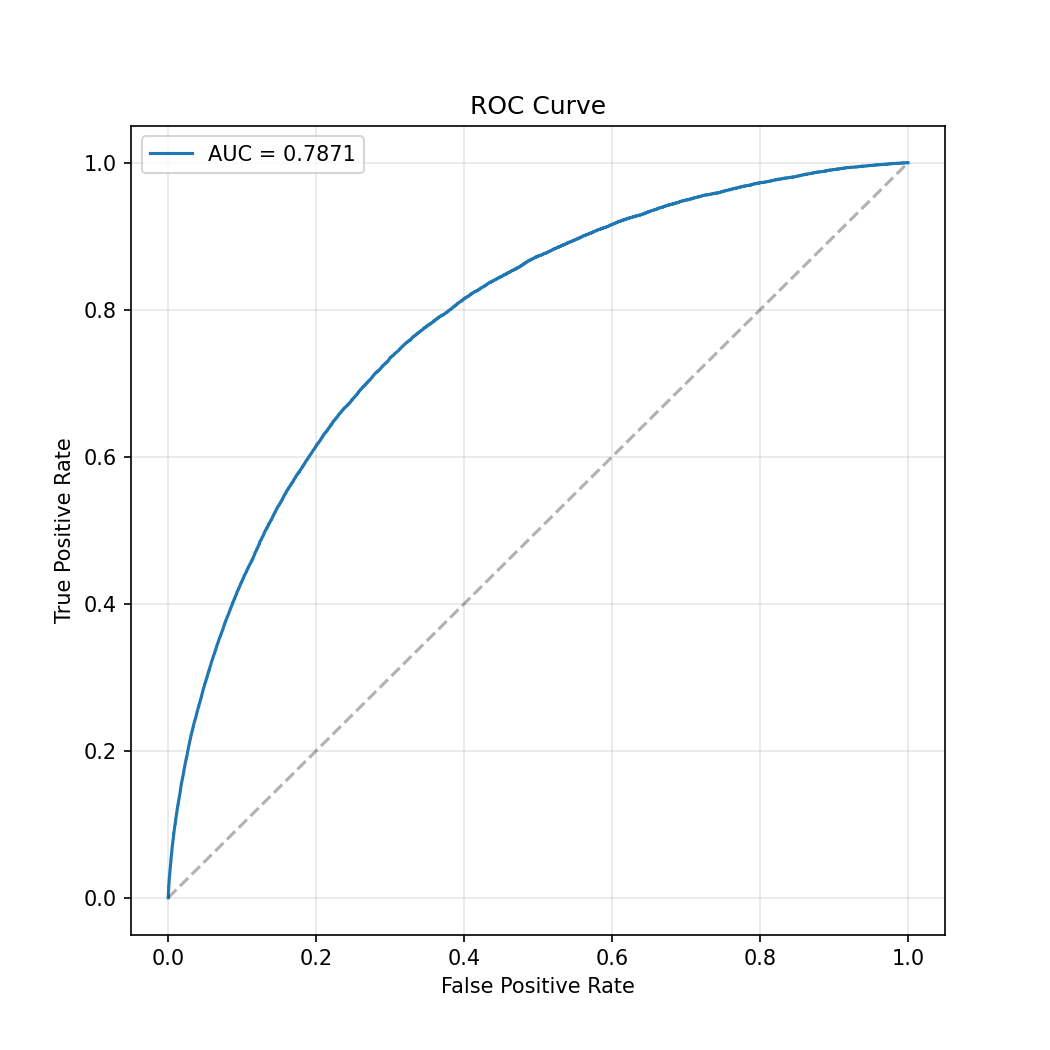

In [14]:
# Display the saved ROC curve
display(Image(filename=str(OUTPUT_DIR / "roc_curve.png"), width=500))

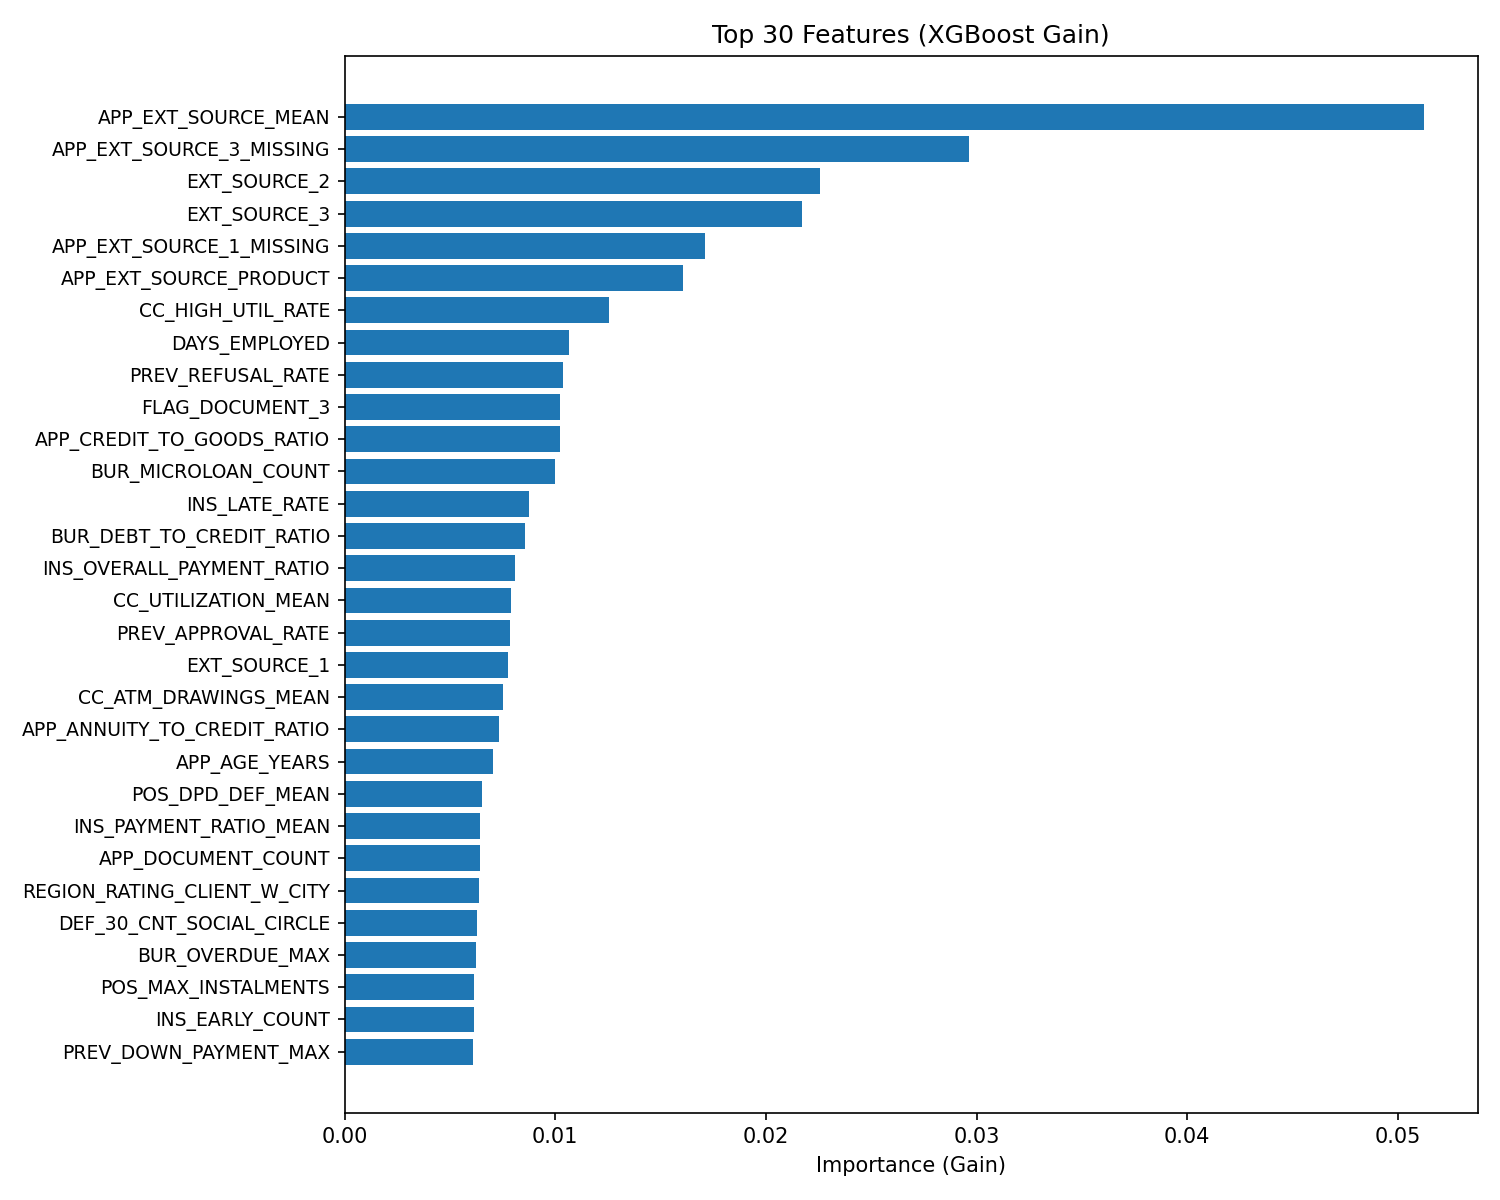

In [15]:
# Feature importance by XGBoost gain
display(Image(filename=str(OUTPUT_DIR / "feature_importance_gain.png"), width=700))

In [16]:
# Top 20 features with their importance scores
feature_names = model_data["feature_names"]
importances = np.mean([m.feature_importances_ for m in model_data["models"]], axis=0)
idx = np.argsort(importances)[::-1][:20]

print("Top 20 Features by Importance (Gain)")
print("=" * 65)
for rank, i in enumerate(idx, 1):
    name = feature_names[i]
    # Annotate what each feature captures
    annotations = {
        "APP_EXT_SOURCE_MEAN": "avg of 3 external credit scores",
        "APP_EXT_SOURCE_3_MISSING": "is external score 3 missing?",
        "EXT_SOURCE_2": "external credit score 2",
        "EXT_SOURCE_3": "external credit score 3",
        "APP_EXT_SOURCE_1_MISSING": "is external score 1 missing?",
        "APP_EXT_SOURCE_PRODUCT": "product of all 3 ext scores",
        "APP_EXT_SOURCE_2x3": "EXT_SOURCE_2 x EXT_SOURCE_3",
        "APP_EXT_SOURCE_1x2": "EXT_SOURCE_1 x EXT_SOURCE_2",
        "APP_EXT_SOURCE_2_MINUS_3": "EXT_SOURCE_2 - EXT_SOURCE_3",
        "APP_EXT_SOURCE_STD": "disagreement among ext scores",
        "APP_EXT_SOURCE_WEIGHTED_MEAN": "weighted avg (favoring 2 & 3)",
        "APP_EXT2_x_AGE": "EXT_SOURCE_2 x applicant age",
        "CC_HIGH_UTIL_RATE": "% months with >90% card utilization",
        "DAYS_EMPLOYED": "employment duration",
        "PREV_REFUSAL_RATE": "% of prev apps that were refused",
        "INS_LATE_RATE": "% of installments paid late",
        "BUR_DEBT_TO_CREDIT_RATIO": "total debt / total credit",
        "CC_UTILIZATION_MEAN": "avg credit card utilization",
        "PREV_APPROVAL_RATE": "% of prev apps that were approved",
        "CC_ATM_DRAWINGS_MEAN": "avg ATM cash advance amount",
        "CROSS_COMBINED_DPD_SCORE": "combined DPD from all tables",
        "CROSS_TOTAL_CREDIT_TO_INCOME": "total credit / income",
        "TE_ORGANIZATION_TYPE": "target-encoded organization type",
        "TE_OCCUPATION_TYPE": "target-encoded occupation type",
        "APP_INCOME_PER_FAMILY_MEMBER": "income per family member",
        "BUR_ACTIVE_DEBT_TO_CREDIT_RATIO": "active debt / active credit",
        "INS_RECENT_12_LATE_RATE": "late rate in last 12 installments",
        "CC_UTIL_TREND_3M": "recent 3mo util vs overall (trend)",
    }
    annotation = annotations.get(name, "")
    ann_str = f"  <- {annotation}" if annotation else ""
    print(f"  {rank:2d}. {name:40s} {importances[i]:.4f}{ann_str}")

Top 20 Features by Importance (Gain)
   1. APP_EXT_SOURCE_WEIGHTED_MEAN             0.0545  <- weighted avg (favoring 2 & 3)
   2. APP_EXT_SOURCE_MEAN                      0.0272  <- avg of 3 external credit scores
   3. APP_EXT_SOURCE_3_MISSING                 0.0215  <- is external score 3 missing?
   4. APP_EXT_SOURCE_STD                       0.0199  <- disagreement among ext scores
   5. APP_EXT_SOURCE_COUNT                     0.0193
   6. APP_EXT_SOURCE_2x3                       0.0127  <- EXT_SOURCE_2 x EXT_SOURCE_3
   7. CC_RECENT_12M_HIGH_UTIL_MONTHS           0.0116
   8. TE_NAME_EDUCATION_TYPE                   0.0110
   9. INS_RECENT_12_LATE_COUNT                 0.0107
  10. EXT_SOURCE_3                             0.0105  <- external credit score 3
  11. INS_RECENT_12_LATE_RATE                  0.0099  <- late rate in last 12 installments
  12. APP_EXT2_x_AGE                           0.0084  <- EXT_SOURCE_2 x applicant age
  13. INS_RECENT_12_PAYMENT_RATIO              

### 4.5 SHAP Analysis

SHAP (SHapley Additive exPlanations) gives us a more nuanced view than gain-based importance. The beeswarm plot shows not just *which* features matter, but *how* they affect predictions — each dot is a sample, colored by its feature value.

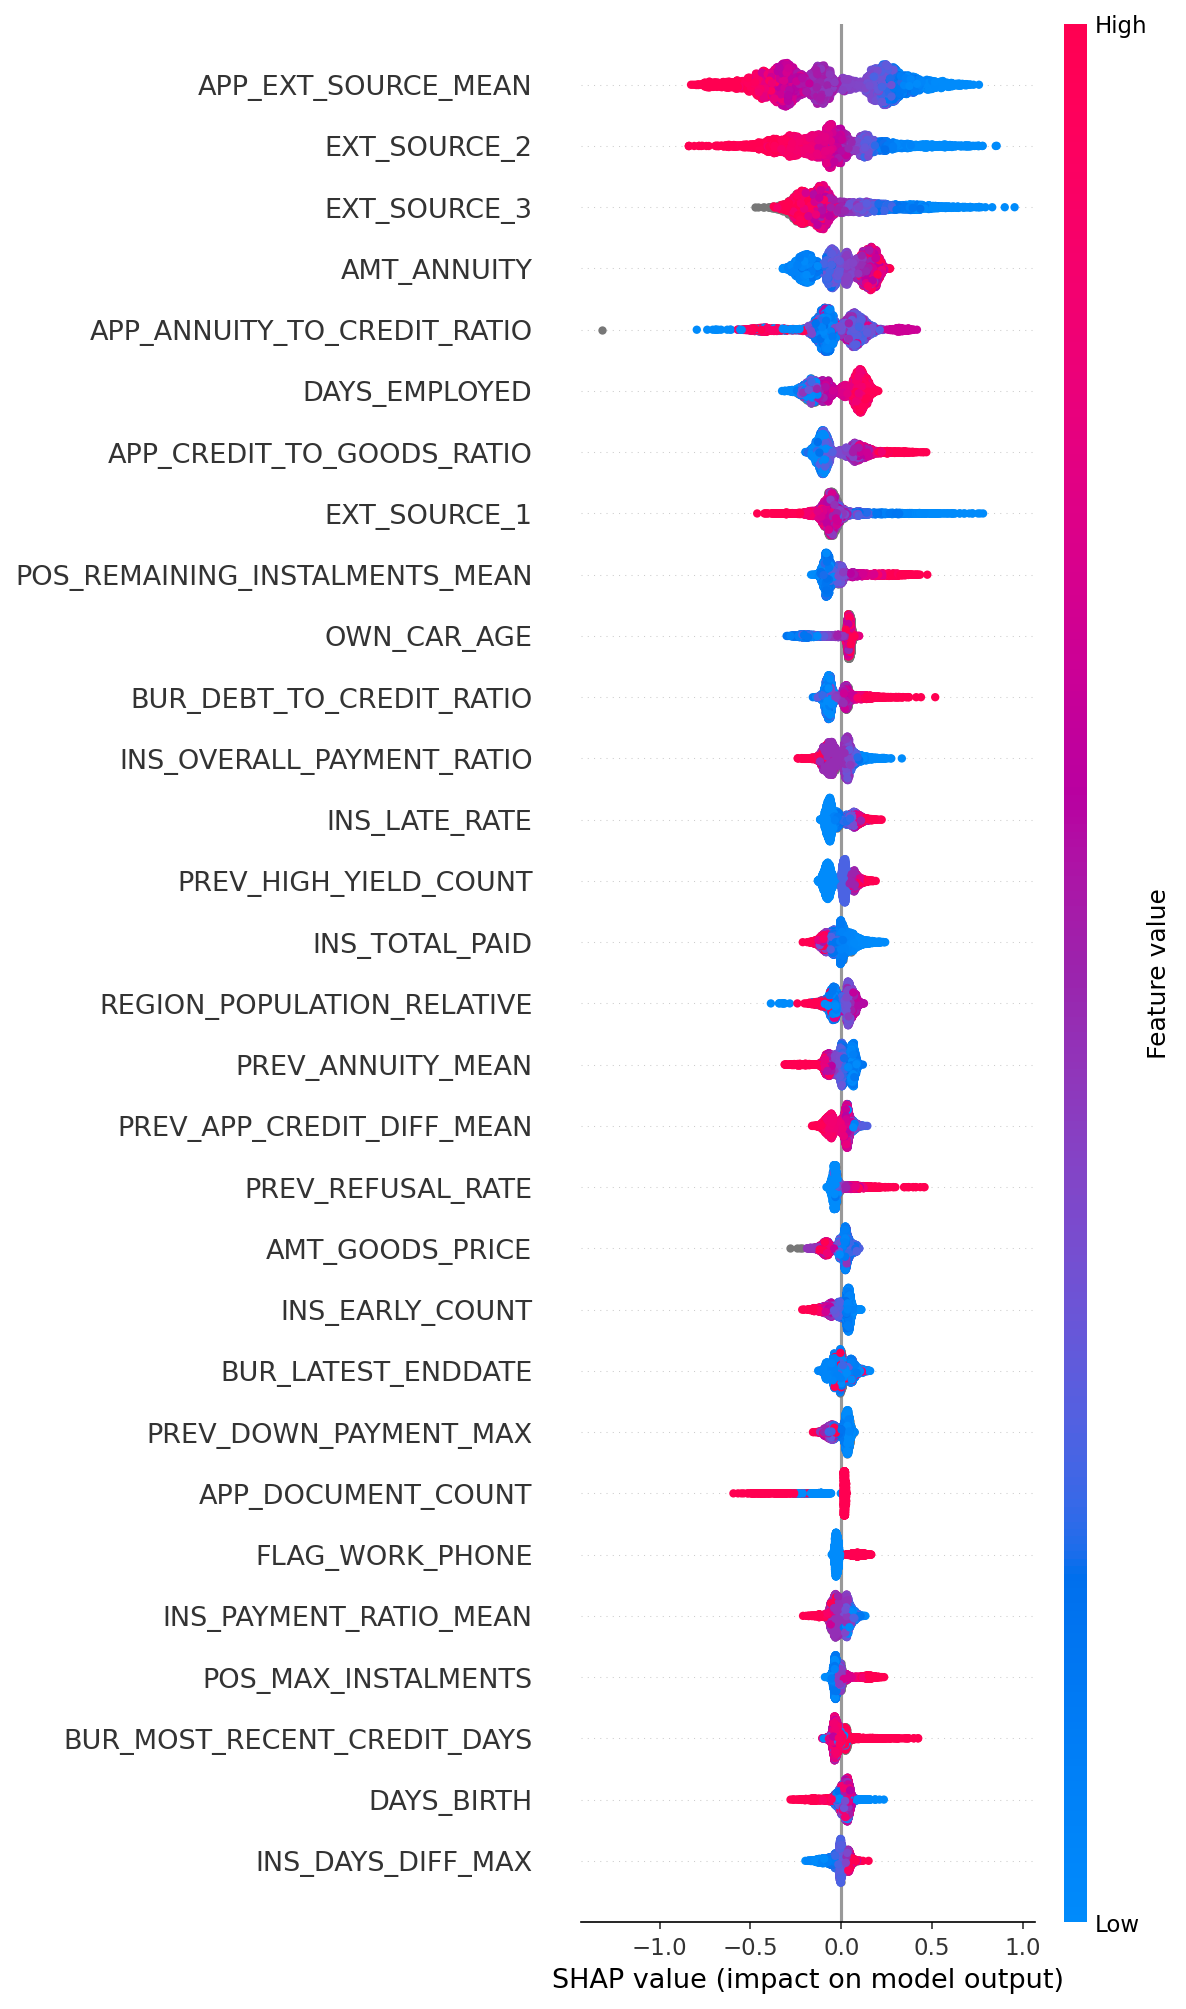

In [17]:
# SHAP summary plot (beeswarm)
display(Image(filename=str(OUTPUT_DIR / "shap_summary.png"), width=700))

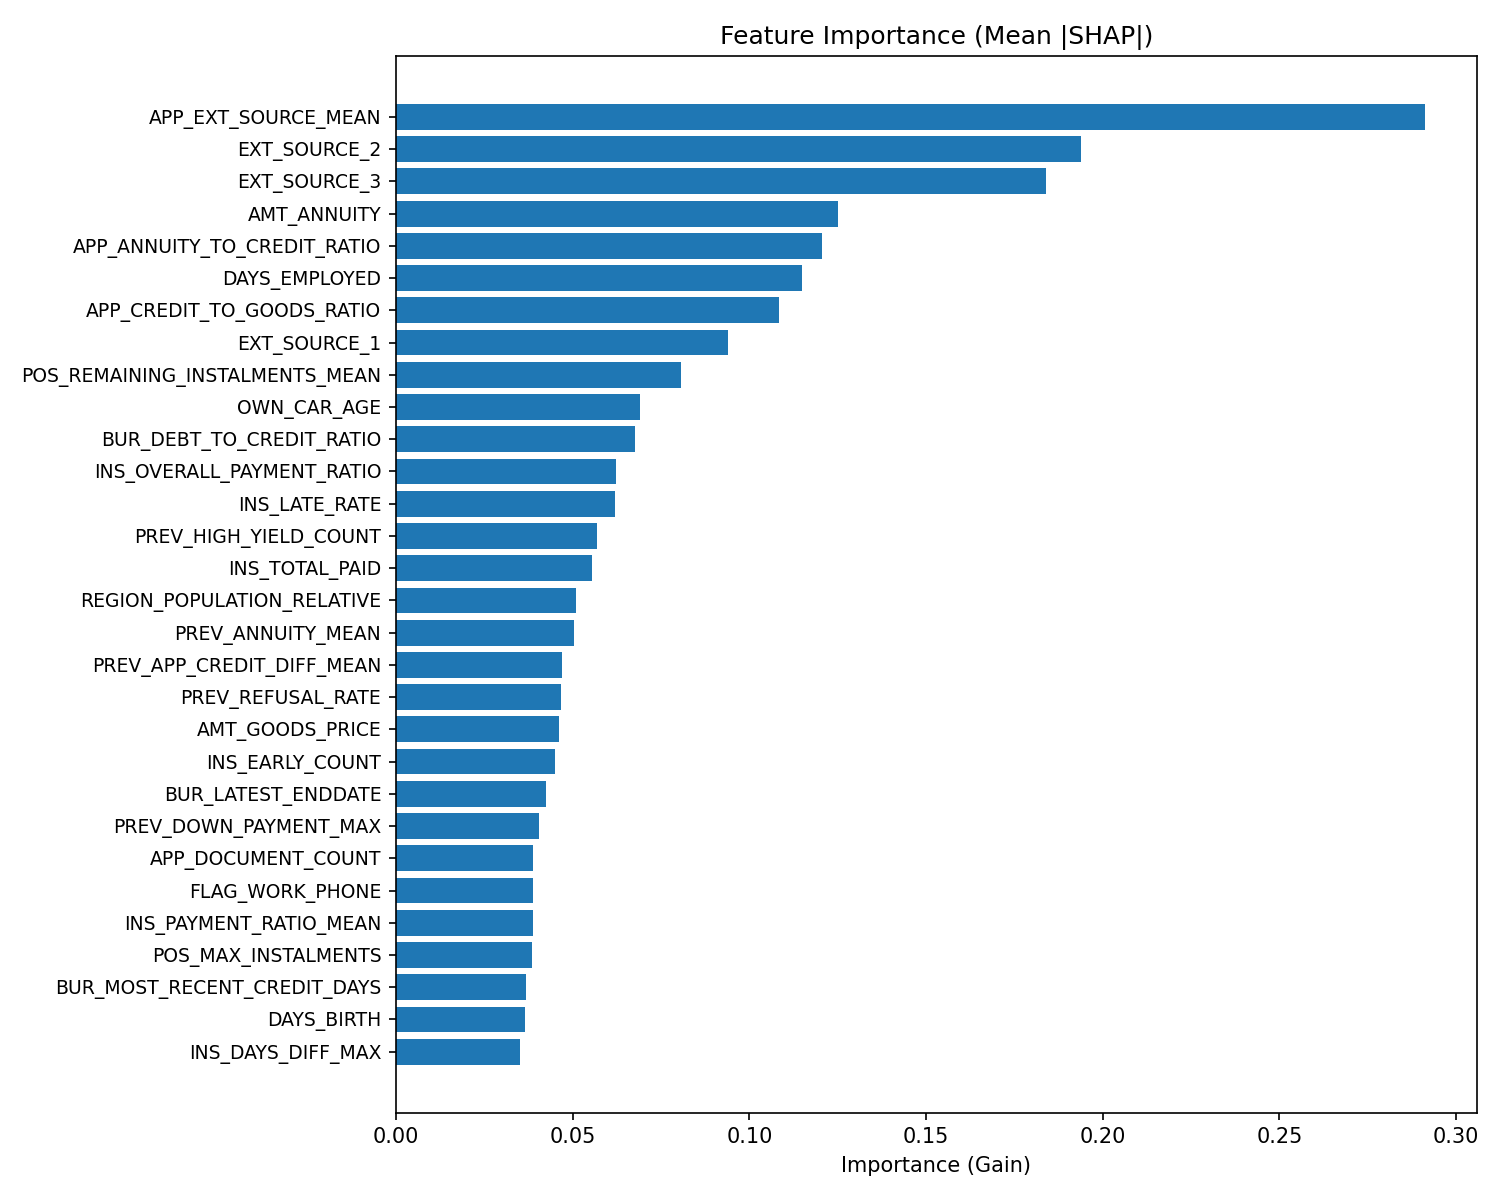

In [18]:
# SHAP-based feature importance (mean absolute SHAP value)
display(Image(filename=str(OUTPUT_DIR / "shap_importance.png"), width=700))

---
## 5. Threshold Analysis

The model outputs a probability of default (0 to 1). In a real deployment, you'd need to pick a **decision threshold** — above this, decline the application. Below it, approve.

This is a critical business decision that trades off:
- **Precision** (of those we decline, how many were actual defaulters?)
- **Recall** (of all actual defaulters, how many did we catch?)
- **Approval rate** (what % of applicants get approved?)

In [19]:
# Threshold analysis table
threshold_df = pl.read_csv(OUTPUT_DIR / "threshold_analysis.csv")
print("Threshold Analysis — How decision boundary affects outcomes:")
print("=" * 90)
display(threshold_df)

# Highlight some business-relevant thresholds
print("\nBusiness interpretation:")
print("-" * 70)
for t in [0.1, 0.2, 0.3, 0.5]:
    row = threshold_df.filter(pl.col("threshold") == t)
    if row.shape[0] > 0:
        r = row.row(0, named=True)
        print(f"  Threshold {t:.0%}: Approve {r['approval_rate']:.0%} of applicants, "
              f"catch {r['recall']:.0%} of defaulters (precision: {r['precision']:.0%})")

Threshold Analysis — How decision boundary affects outcomes:


threshold,precision,recall,f1,approval_rate,decline_rate,true_positives,false_positives
f64,f64,f64,f64,f64,f64,i64,i64
0.05,0.0998,0.9646,0.181,0.2201,0.7799,23946,215893
0.1,0.134,0.8699,0.2322,0.4757,0.5243,21596,139622
0.15,0.1684,0.7631,0.276,0.6343,0.3657,18943,93524
0.2,0.2011,0.6541,0.3076,0.7374,0.2626,16239,64513
0.25,0.2327,0.5533,0.3276,0.8081,0.1919,13736,45286
…,…,…,…,…,…,…,…
0.7,0.5533,0.046,0.0849,0.9933,0.0067,1142,922
0.75,0.6151,0.0263,0.0504,0.9966,0.0034,652,408
0.8,0.6652,0.0119,0.0234,0.9986,0.0014,296,149



Business interpretation:
----------------------------------------------------------------------
  Threshold 10%: Approve 48% of applicants, catch 87% of defaulters (precision: 13%)
  Threshold 20%: Approve 74% of applicants, catch 65% of defaulters (precision: 20%)
  Threshold 30%: Approve 86% of applicants, catch 46% of defaulters (precision: 26%)
  Threshold 50%: Approve 96% of applicants, catch 19% of defaulters (precision: 40%)


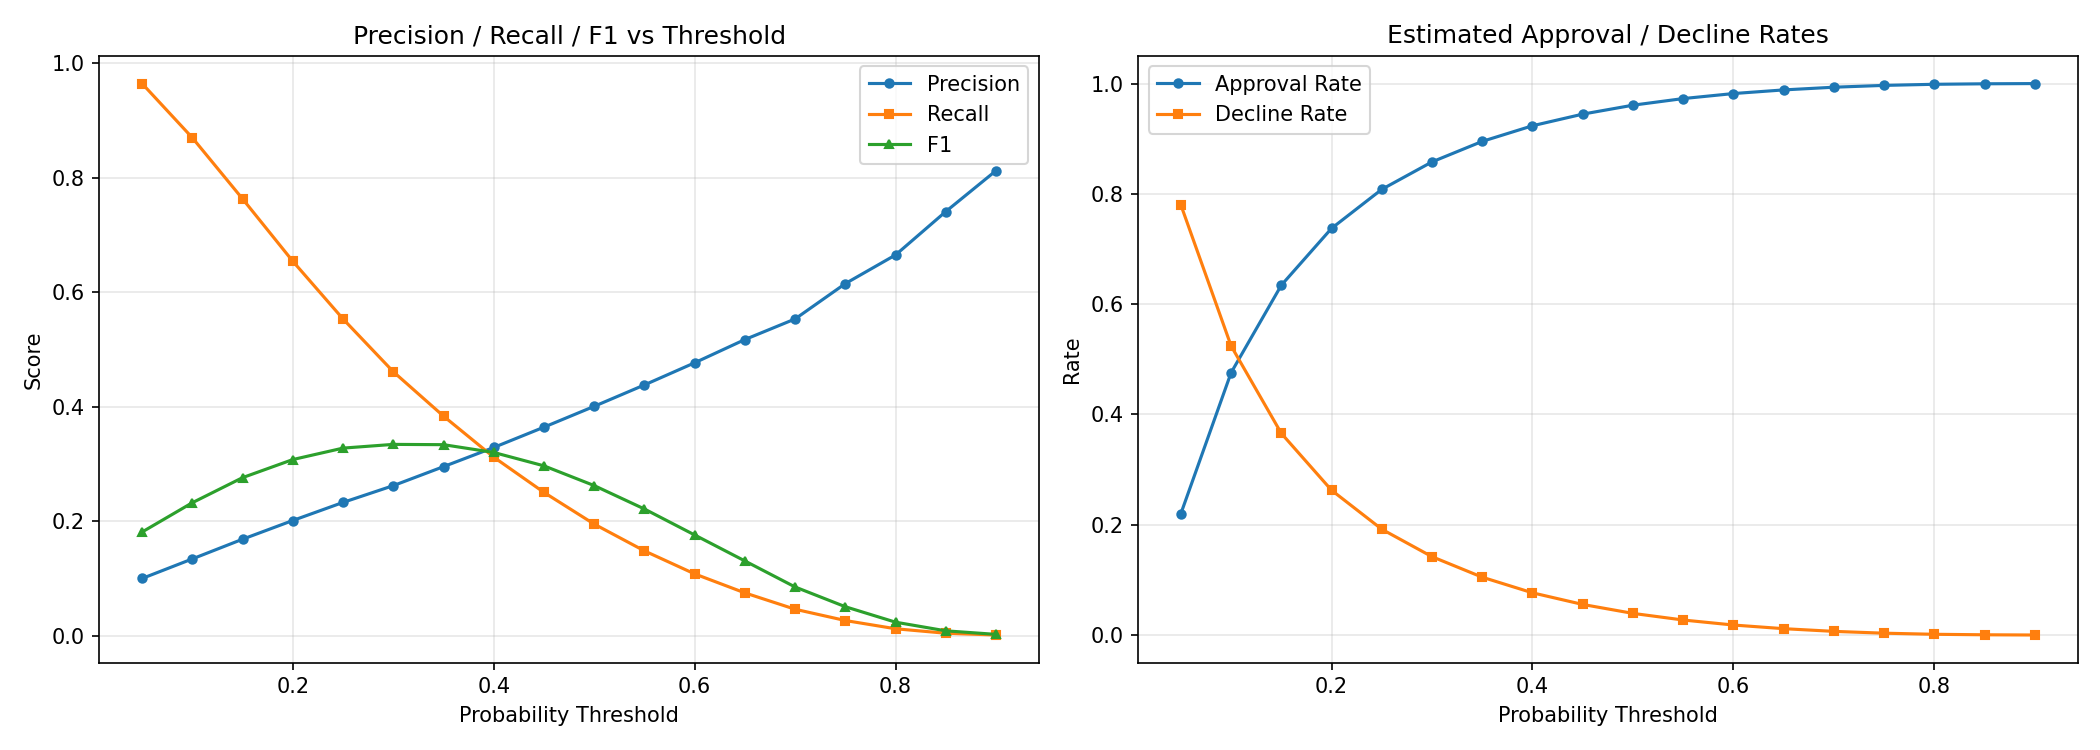

In [20]:
# Threshold analysis plots
display(Image(filename=str(OUTPUT_DIR / "threshold_analysis.png"), width=800))

---
## 6. Kaggle Submissions — Validating Our Pipeline

The ultimate test of our pipeline is whether the **CV score tracks with the Kaggle leaderboard score**. A big gap between CV and LB would indicate overfitting or a data leak.

We submitted three times:
1. **Baseline** — after the first working model (to establish a reference point)
2. **Tuned** — after hyperparameter tuning with Optuna
3. **V2 Blend** — after feature engineering overhaul, target encoding, and XGB+LGB blending

### How Submissions Work

For each submission, we:
1. Load all 5 fold models (for both XGBoost and LightGBM in the blended case)
2. Generate predictions on the test set with each model
3. **Average** the 5 sets of predictions per model, then **blend** XGB and LGB predictions
4. Save as CSV with columns `SK_ID_CURR` and `TARGET`
5. Upload via `kaggle competitions submit`

In [21]:
# Show submission log
sub_log = pl.read_csv(OUTPUT_DIR / "submission_log.csv")
print("Kaggle Submission History:")
print("=" * 80)
display(sub_log)

# Show the submission file format
submission = pl.read_csv(OUTPUT_DIR / "submission.csv")
print(f"\nSubmission file: {submission.shape[0]:,} rows, columns: {submission.columns}")
print(f"TARGET range: [{submission['TARGET'].min():.4f}, {submission['TARGET'].max():.4f}]")
print(f"TARGET mean: {submission['TARGET'].mean():.4f} (should be close to 8.1% base rate)")
print(f"\nFirst 5 rows:")
display(submission.head(5))

print("\nPrediction distribution:")
print(submission["TARGET"].describe())

Kaggle Submission History:


timestamp,message,cv_score,n_features,kaggle_public_lb,kaggle_private_lb
str,str,f64,i64,f64,f64
"""2026-02-09T00:22:25.332459""","""Baseline: XGBoost default params, 266 features, CV AUC 0.785…",0.785681,266,0.7904,0.78589
"""2026-02-09T02:53:02.513731""","""Tuned: XGBoost lr=0.03 depth=5, 220 features, CV AUC 0.7871""",0.787137,220,0.79115,0.78648
"""2026-02-09T10:22:06.000000""","""V2 blend: XGB(0.68)+LGB(0.32), 311 features, CV AUC 0.7930""",0.792982,311,0.79659,0.79331



Submission file: 48,744 rows, columns: ['SK_ID_CURR', 'TARGET']
TARGET range: [0.0026, 0.8733]
TARGET mean: 0.1379 (should be close to 8.1% base rate)

First 5 rows:


SK_ID_CURR,TARGET
i64,f64
100001,0.058343
100005,0.30374
100013,0.094736
100028,0.078075
100038,0.262745



Prediction distribution:
shape: (9, 2)
┌────────────┬──────────┐
│ statistic  ┆ value    │
│ ---        ┆ ---      │
│ str        ┆ f64      │
╞════════════╪══════════╡
│ count      ┆ 48744.0  │
│ null_count ┆ 0.0      │
│ mean       ┆ 0.137904 │
│ std        ┆ 0.130156 │
│ min        ┆ 0.002554 │
│ 25%        ┆ 0.046418 │
│ 50%        ┆ 0.091588 │
│ 75%        ┆ 0.184849 │
│ max        ┆ 0.873299 │
└────────────┴──────────┘


### CV Score vs Kaggle Leaderboard

The key validation question: **does our local CV score track with what Kaggle reports?**

We fetch the actual Kaggle scores programmatically using `kaggle competitions submissions --csv` and sync them into our submission log. Let's compare:

In [22]:
# Load the submission log with Kaggle scores
sub_log = pl.read_csv(OUTPUT_DIR / "submission_log.csv")
display(sub_log)

# Compute the gap between CV and Kaggle scores
print("\nCV vs Kaggle Leaderboard Comparison:")
print("=" * 85)
print(f"{'Model':<45} {'CV AUC':>8} {'Public LB':>10} {'Private LB':>11} {'CV-Pub Gap':>11}")
print("-" * 85)
for row in sub_log.iter_rows(named=True):
    cv = float(row["cv_score"])
    pub = float(row["kaggle_public_lb"])
    priv = float(row["kaggle_private_lb"])
    gap = pub - cv
    name = row["message"][:43]
    print(f"{name:<45} {cv:>8.5f} {pub:>10.5f} {priv:>11.5f} {gap:>+11.5f}")

print("\nPositive gap = Kaggle scored HIGHER than local CV (no overfitting)")
print("Negative gap = Kaggle scored LOWER than local CV (potential overfit)")

timestamp,message,cv_score,n_features,kaggle_public_lb,kaggle_private_lb
str,str,f64,i64,f64,f64
"""2026-02-09T00:22:25.332459""","""Baseline: XGBoost default params, 266 features, CV AUC 0.785…",0.785681,266,0.7904,0.78589
"""2026-02-09T02:53:02.513731""","""Tuned: XGBoost lr=0.03 depth=5, 220 features, CV AUC 0.7871""",0.787137,220,0.79115,0.78648
"""2026-02-09T10:22:06.000000""","""V2 blend: XGB(0.68)+LGB(0.32), 311 features, CV AUC 0.7930""",0.792982,311,0.79659,0.79331



CV vs Kaggle Leaderboard Comparison:
Model                                           CV AUC  Public LB  Private LB  CV-Pub Gap
-------------------------------------------------------------------------------------
Baseline: XGBoost default params, 266 featu    0.78568    0.79040     0.78589    +0.00472
Tuned: XGBoost lr=0.03 depth=5, 220 feature    0.78714    0.79115     0.78648    +0.00401
V2 blend: XGB(0.68)+LGB(0.32), 311 features    0.79298    0.79659     0.79331    +0.00361

Positive gap = Kaggle scored HIGHER than local CV (no overfitting)
Negative gap = Kaggle scored LOWER than local CV (potential overfit)


---
## 7. Summary & Key Takeaways

### What We Built
- A complete, production-quality ML pipeline from raw data to Kaggle submission
- 374 domain-informed features from 8 interconnected tables, pruned to 311 by importance
- XGBoost + LightGBM blend with target encoding for high-cardinality categoricals
- **CV AUC 0.7930, Kaggle Public LB 0.7966, Private LB 0.7933**

### Progression

| Iteration | Features | CV AUC | Public LB | Private LB |
|-----------|----------|--------|-----------|------------|
| Baseline (default XGB) | 266 | 0.7857 | 0.7904 | 0.7859 |
| Tuned XGB (Optuna) | 220 | 0.7871 | 0.7912 | 0.7865 |
| **V2 Blend (XGB+LGB)** | **311** | **0.7930** | **0.7966** | **0.7933** |

### CV–Kaggle Alignment

Our Kaggle public LB scores were consistently **higher** than local CV (~+0.003 to +0.004), indicating a healthy pipeline with no overfitting. The private LB scores tracked very closely with public LB, confirming our cross-validation was well-calibrated.

### What Predicts Default

The most important predictors fall into clear categories:

1. **External credit scores** (EXT_SOURCE_1/2/3) — These are pre-computed scores from credit bureaus and dominate the model. Their *missingness*, *pairwise interactions*, and *variance* are all informative.

2. **Credit card behavior** — High utilization rates (>90%), ATM cash advances, and worsening utilization trends signal financial stress.

3. **Payment history** — Late payment rates from installment data, especially recent behavior, directly measure repayment discipline.

4. **Application history** — Previous application refusal rates indicate the applicant has been flagged before.

5. **Employment stability** — Longer employment duration correlates with lower default risk.

6. **Cross-table signals** — Combined DPD scores across tables, total debt-to-income ratios, and first-time applicant flags capture risk that no single table reveals.

### Pipeline Architecture

```
Raw CSVs (Kaggle)
    ↓ Polars load_table (eager, dtype-optimized)
Feature Engineering (per table, aggregated to SK_ID_CURR)
    ↓ Cached as parquet
Join all features + cross-table interactions → Single training DataFrame
    ↓ Convert to numpy + per-fold target encoding
XGBoost + LightGBM (5-fold stratified CV each)
    ↓ Find optimal blend weight via OOF predictions
Blended predictions → Submission CSV → Kaggle API
    ↓ kaggle competitions submissions --csv
Score sync → submission_log.csv (CV + public + private LB)
```

### Key Techniques That Drove Improvement
- **EXT_SOURCE pairwise interactions** — Products, differences, and variance among external scores
- **Time-windowed aggregations** — Recent 3/6/12 month behavior vs all-time (recent matters more)
- **Target encoding** — Smoothed per-fold encoding of ORGANIZATION_TYPE, OCCUPATION_TYPE, etc.
- **Model blending** — XGBoost (0.68) + LightGBM (0.32) reduces individual model bias
- **Feature pruning** — Removing low-importance features improves generalization